In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from spectral_cube import SpectralCube
from turbustat.simulator import make_ppv
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
from skimage.util import random_noise
import corner

In [2]:
# Add path to py_modules 

sys.path.append(str(Path().resolve().parents[0] / 'py_modules')) # 1 level up = project root
from turb_utils import make_extended, make_3dfield
import strucfunc
import bfunc
import bplot
from rebin_utils import downsample


# confidence intervals user def MOD

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit

def fit_structure_function(
    data_in,
    N,
    bfunc,
    bplot,
    name='name',
    data='data',
    pc_per_arcsec=1,
    relative_uncertainty=0.07,
    emcee_steps=50000,
    emcee_burn=500,
    emcee_thin=50,
    emcee_workers=16,
    bins = 1
):
    """
    Fits a structure function model to the input data and performs MCMC sampling.
    # Modification for binning test
    
    Parameters
    ----------
    sf_noise_2 : dict or DataFrame-like
        Must have keys: 'N pairs', 'Unweighted B(r)', 'log10 r'
    N : float
        Box size parameter.
    bfunc : module or object
        Must have attribute bfunc03s (model function).
    bplot : module or object
        Must provide corner_plot and strucfunc_plot functions.
    name : str
        Name identifier for plots.
    data : str
        Data identifier for plots.
    pc_per_arcsec : float
        Conversion factor for arcsec to pc.
    relative_uncertainty : float
        Relative uncertainty for weighting.
    emcee_steps : int
        Number of MCMC steps.
    emcee_burn : int
        Number of MCMC burn-in steps.
    emcee_thin : int
        MCMC thinning factor.
    emcee_workers : int
        Number of parallel workers for emcee.
    
    Returns
    -------
    results : dict
        Contains 'result' (LMFit minimize result) and 'result_emcee' (MCMC result).
    """

    # Mask valid data
    mask = np.array(data_in["N pairs"]) > 0
    B = np.array(data_in['Unweighted B(r)'])[mask]
    r = np.array(10 ** np.array(data_in['log10 r']))[mask] * bins
    box_size = N

    # Model
    model = lmfit.Model(bfunc.bfunc03s)

    # Set parameter hints
    model.set_param_hint("r0", value=0.1 * box_size, min=0.01 * box_size, max=2.0 * box_size)
    model.set_param_hint("sig2", value=0.5 * B.max(), min=0.25 * B.max(), max=2.0 * B.max())
    model.set_param_hint("m", value=1.0, min=0.5, max=2.0)
    model.set_param_hint("s0", value=0.5 * pc_per_arcsec, min=0.1 * pc_per_arcsec, max=1.5 * pc_per_arcsec)
    model.set_param_hint("noise", value=0.5 * B.min(), min=0.0, max=3 * B.min())
    # model.set_param_hint("box_size", value=box_size, vary=False)

    # Weights
    weights = 1.0 / (relative_uncertainty * B)
    large_scale = r > 0.5 * box_size
    # Optional: weights[large_scale] /= 1.25
    # Optional: weights[:1] /= 2.0

    to_fit = r <= 0.6 * box_size
    result = model.fit(B[to_fit], weights=weights[to_fit], r=r[to_fit])

    # MCMC with emcee
    emcee_kws = dict(
        steps=emcee_steps,
        burn=emcee_burn,
        thin=emcee_thin,
        is_weighted=True,
        progress=False,
        workers=emcee_workers,
    )
    emcee_params = result.params.copy()
    # Optionally add lnsigma parameter here if needed

    result_emcee = model.fit(
        data=B[to_fit],
        r=r[to_fit],
        weights=weights[to_fit],
        params=emcee_params,
        method="emcee",
        nan_policy="omit",
        fit_kws=emcee_kws,
    )

    # Plot acceptance fraction
    plt.figure()
    plt.plot(result_emcee.acceptance_fraction, "o")
    plt.xlabel("walker")
    plt.ylabel("acceptance fraction")
    plt.title("MCMC Acceptance Fraction")
    plt.show()

    # Print autocorrelation times
    if hasattr(result_emcee, "acor"):
        print("Autocorrelation time for the parameters:")
        print("----------------------------------------")
        for i, p in enumerate(result_emcee.params):
            try:
                print(f"{p} = {result_emcee.acor[i]:.3f}")
            except IndexError:
                pass

    # Corner plot
    bplot.corner_plot(
        result_emcee, result, name, data, data_ranges=[0.95, 0.99, 0.995, 0.997, 0.999]
    )

    # Structure function plot
    bplot.strucfunc_plot(
        result_emcee, result, r, B, to_fit, name, data, box_size, large_scale
    )

    # Return fit results
    return {'result': result, 'result_emcee': result_emcee}


# Original Map

In [8]:
# Physical parameters

r0 = 32.0
N = 512
#m3D = 0.30
m2D = 1.2
#sig_E = 1

In [9]:
vmap2D = make_extended(N,
    powerlaw           = 2.0 + m2D,
    correlation_length = r0,  
  #  amp                = 1.0,                      No amp in 2D
    ellip              = 0.5,
    theta              = 45,
    randomseed         = 2025_10_01)#* u.km / u.s   No units in 2D

sig       = vmap2D.std()
vmap2D /= sig

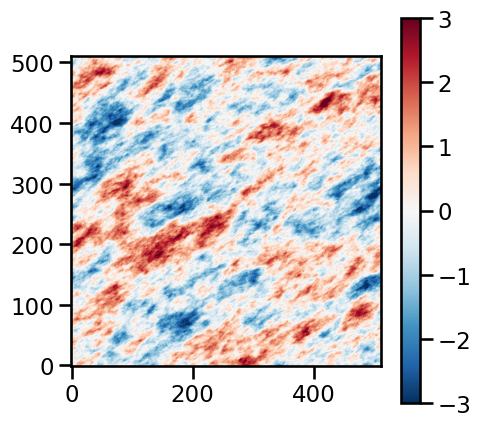

In [10]:


fig, ax = plt.subplots(
    1,
    1,
    #sharey=True,
    figsize=(5, 5),
)

imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap2D, **imshow_kwds)
fig.colorbar(im)
plt.show()

In [11]:
sf = strucfunc.strucfunc_numba_parallel(vmap2D, dlogr=0.05)


C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


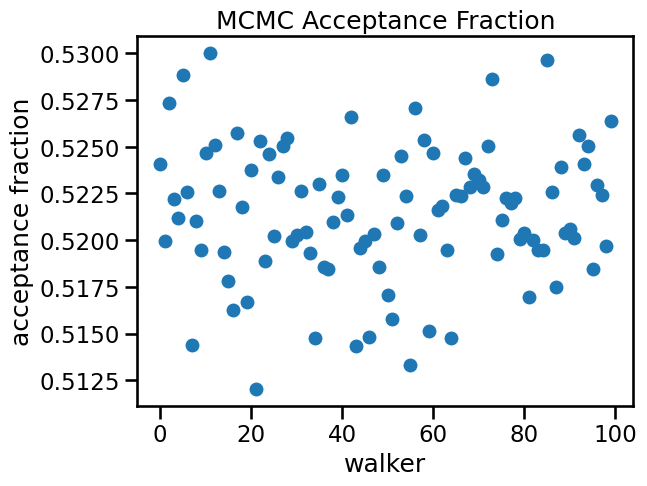

Autocorrelation time for the parameters:
----------------------------------------
r0 = 63.964
sig2 = 66.687
m = 65.640
s0 = 80.586
noise = 107.360


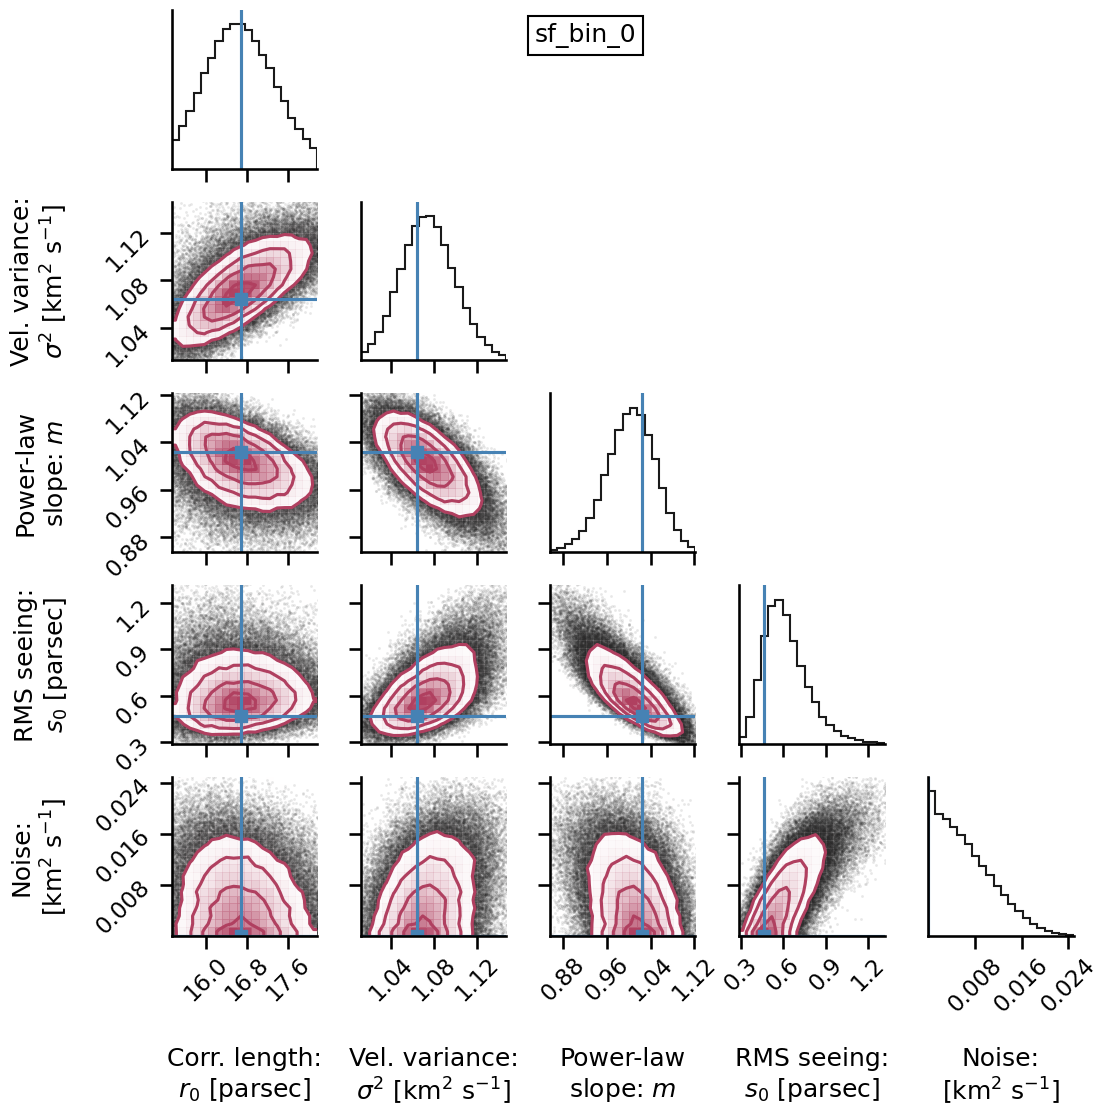

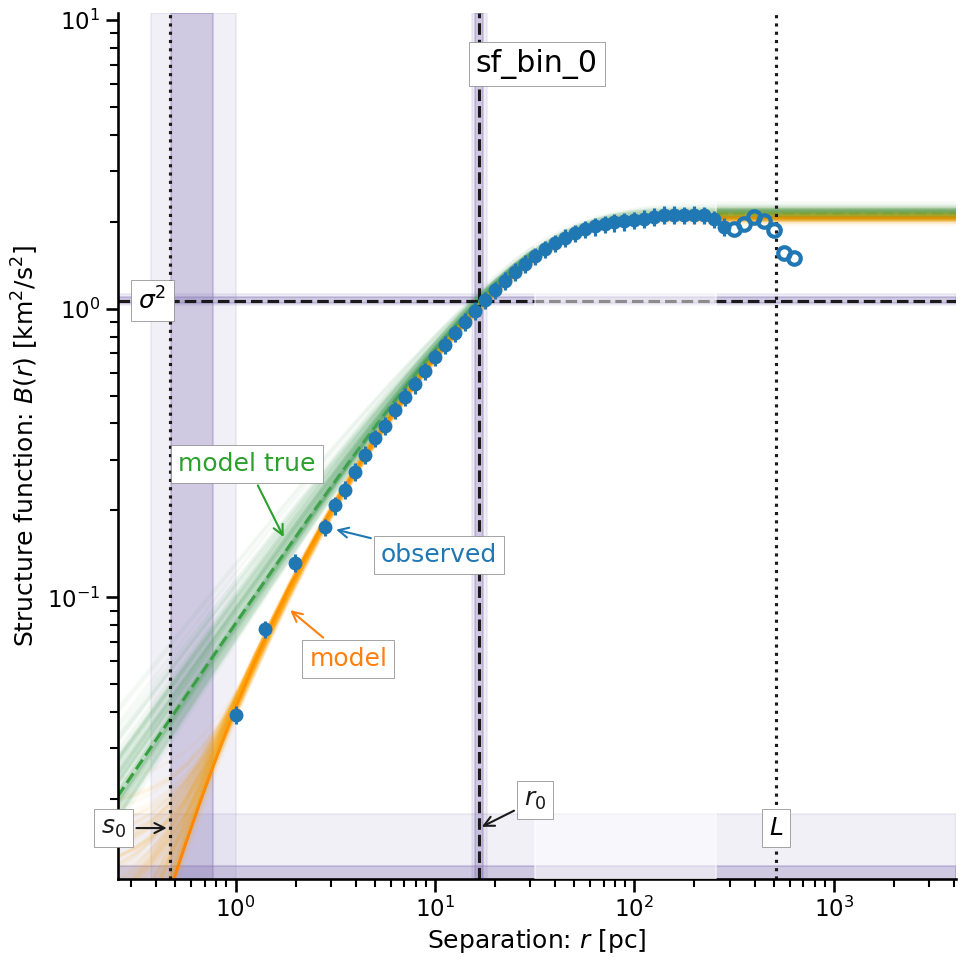

In [12]:
results = fit_structure_function(sf, N=512, bfunc=bfunc, bplot=bplot, name = 'sf_bin_0', data = 'sf_bin_0')

# bin 1

In [13]:
vmap2D_       = pd.notna(vmap2D)
bins = 1

mingoods  = [1]*bins

for mingood in zip(mingoods):
 [vmap2Dx], vmap2Dx_= downsample([vmap2D], vmap2D_, mingood=mingood)


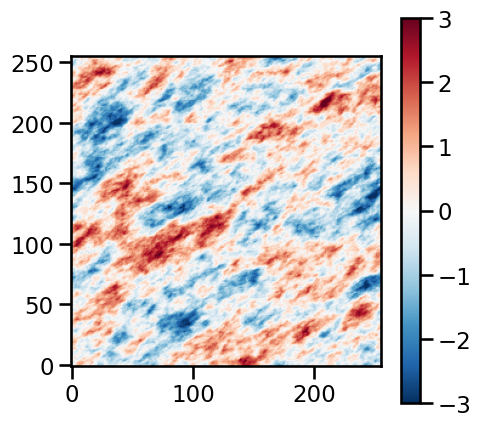

In [14]:

fig, ax = plt.subplots(
    1,
    1,
    #sharey=True,
    figsize=(5, 5),
)

imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap2Dx, **imshow_kwds)
fig.colorbar(im)
plt.show()

In [15]:
sfx = strucfunc.strucfunc_numba_parallel(vmap2Dx, dlogr=0.05)


C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


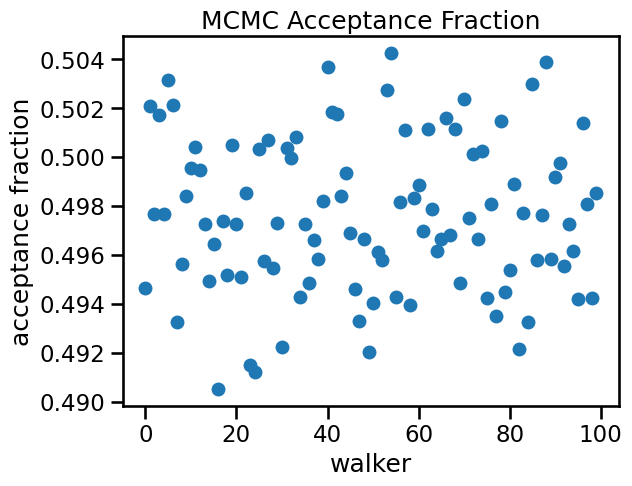

Autocorrelation time for the parameters:
----------------------------------------
r0 = 69.263
sig2 = 71.380
m = 72.984
s0 = 77.872
noise = 100.236


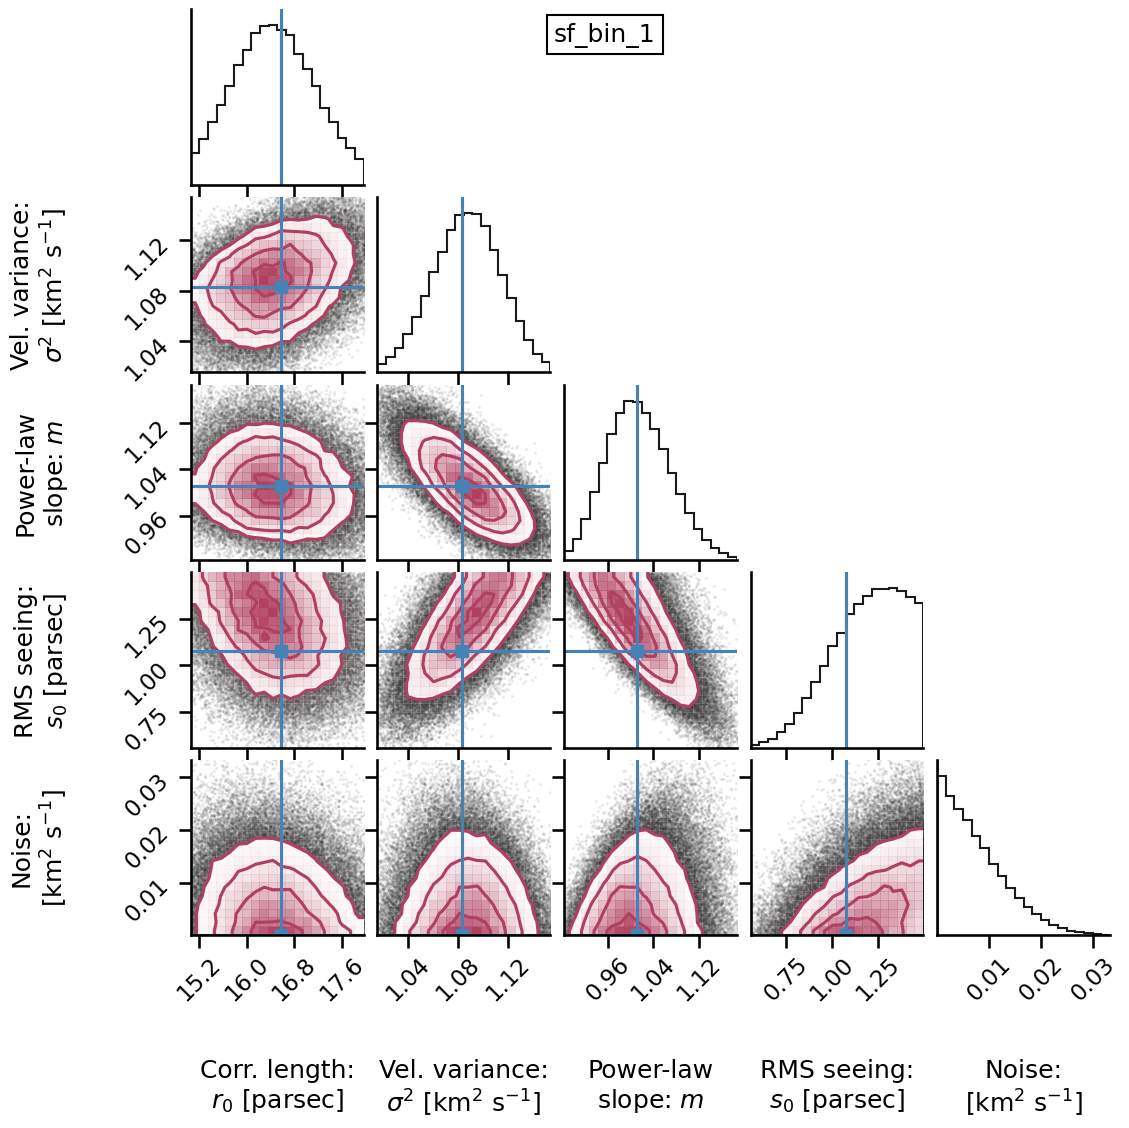

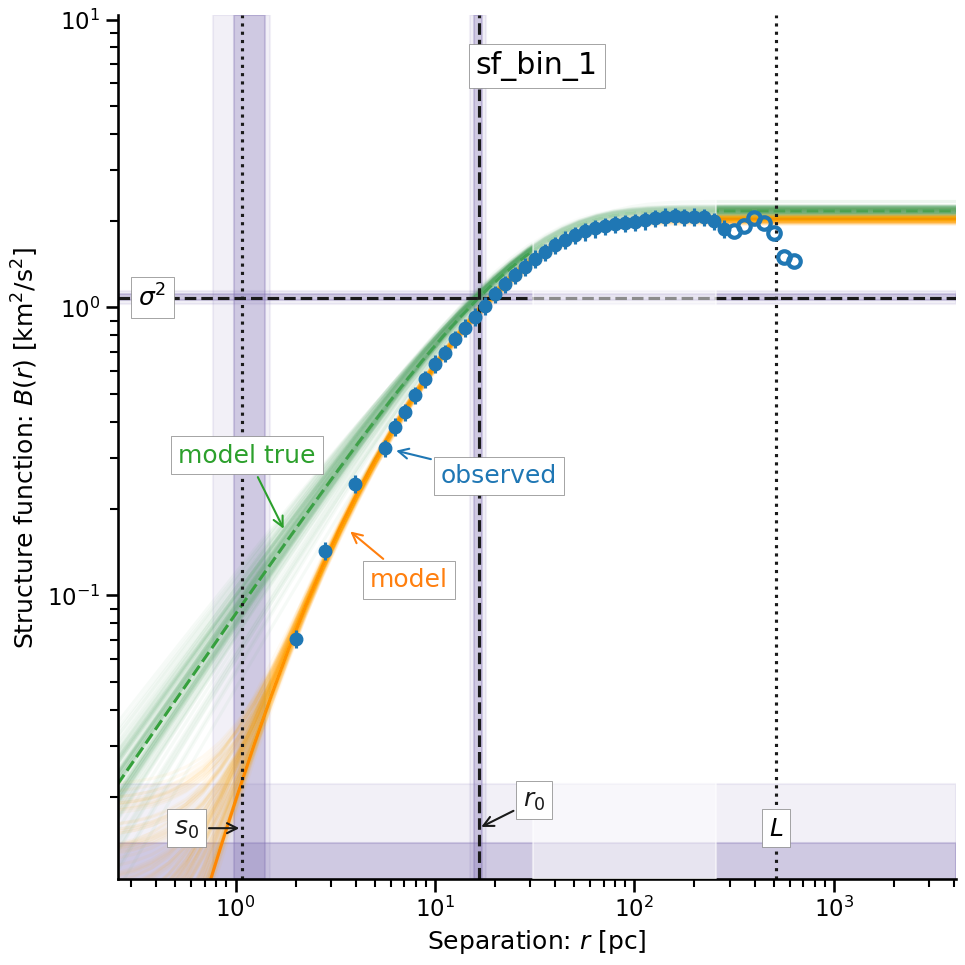

In [34]:
resultsx = fit_structure_function(sfx, N=512, bfunc=bfunc, bplot=bplot, name = 'sf_bin_1', data = 'sf_bin_1', bins = 2)

# bin 2

In [17]:
vmap2Dx_       = pd.notna(vmap2Dx)
bins = 1
mingoods  = [1]*bins

for mingood in zip(mingoods):
 [vmap2Dy], vmap2Dy_= downsample([vmap2Dx], vmap2Dx_, mingood=mingood)


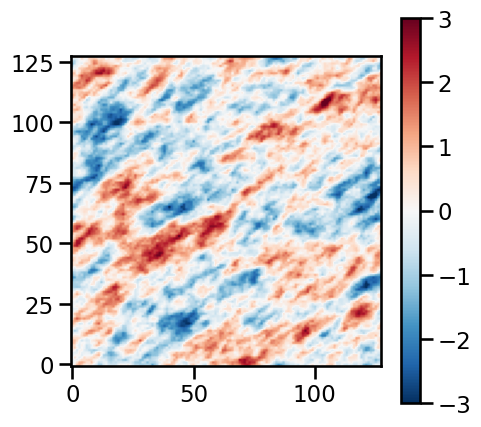

In [18]:

fig, ax = plt.subplots(
    1,
    1,
    #sharey=True,
    figsize=(5, 5),
)

imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap2Dy, **imshow_kwds)
fig.colorbar(im)
plt.show()

In [19]:
sfy = strucfunc.strucfunc_numba_parallel(vmap2Dy, dlogr=0.05)


C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


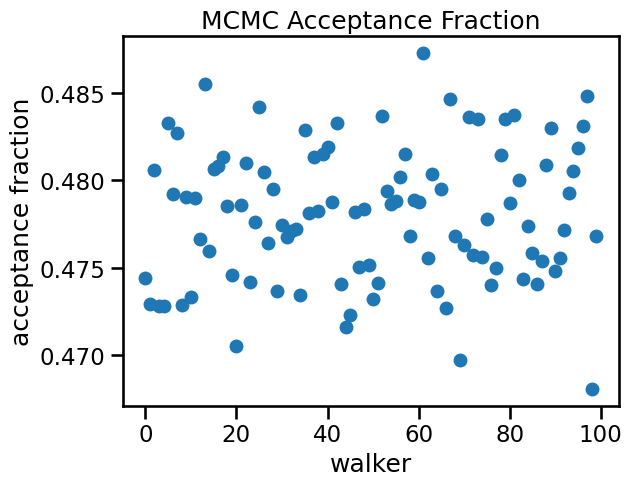

Autocorrelation time for the parameters:
----------------------------------------
r0 = 76.869
sig2 = 85.958
m = 85.782
s0 = 94.636
noise = 105.960


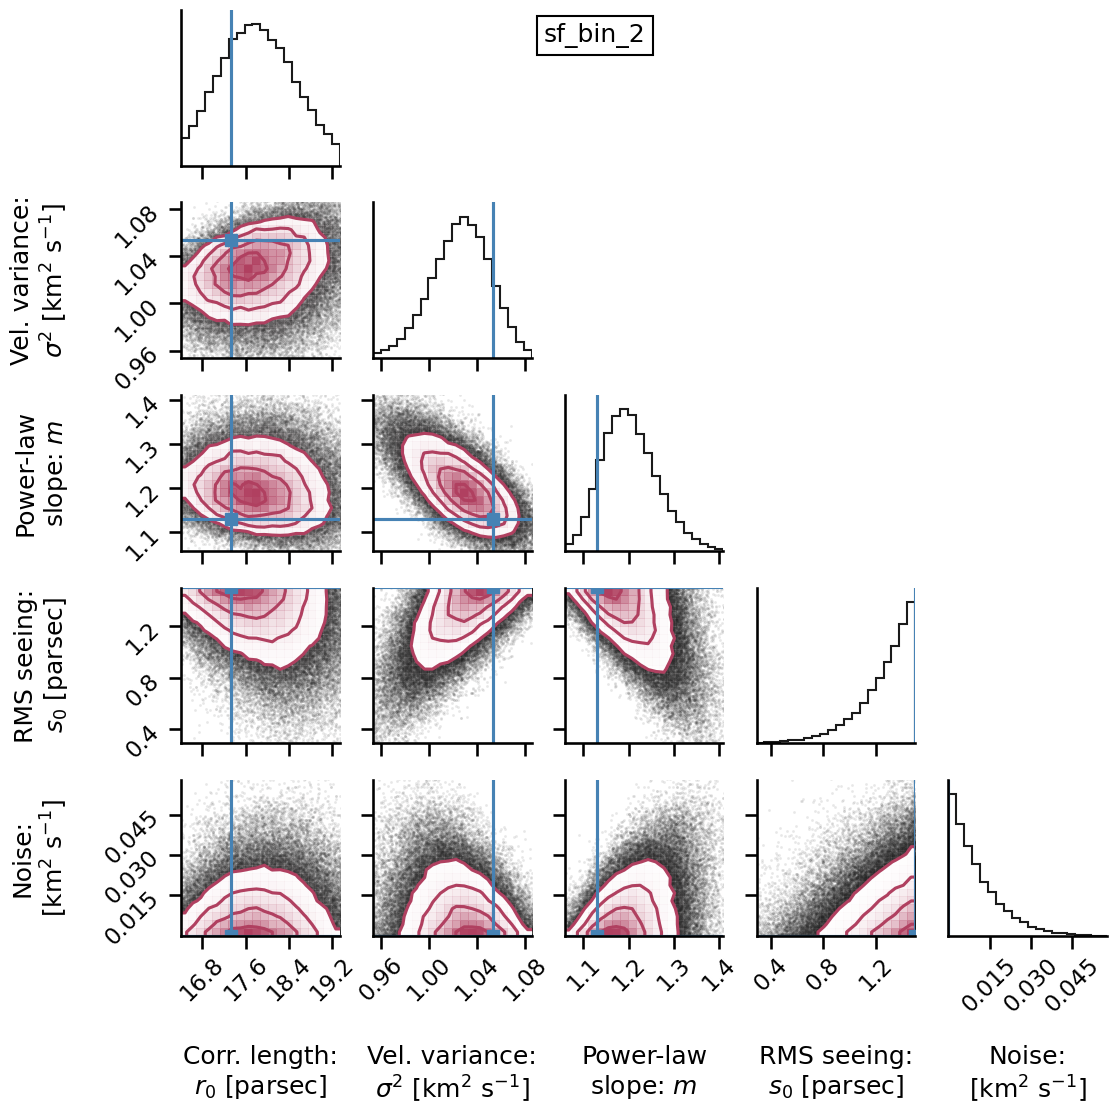

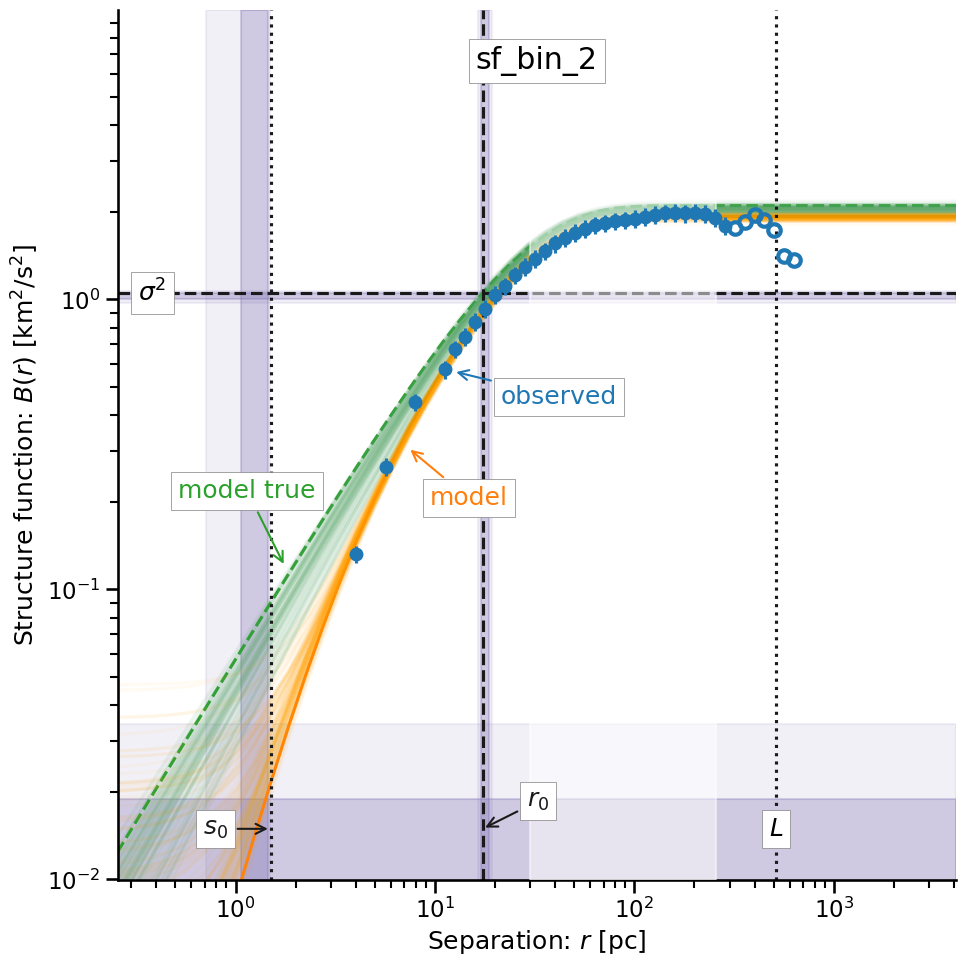

In [35]:
resultsy = fit_structure_function(sfy, N=512, bfunc=bfunc, bplot=bplot, name = 'sf_bin_2', data = 'sf_bin_2', bins = 4)

# bin 3

In [21]:
vmap2Dy_       = pd.notna(vmap2Dy)
bins = 1
mingoods  = [1]*bins

for mingood in zip(mingoods):
 [vmap2Dz], vmap2Dz_= downsample([vmap2Dy], vmap2Dy_, mingood=mingood)


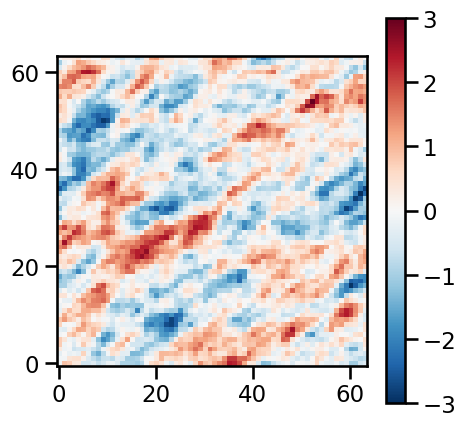

In [22]:

fig, ax = plt.subplots(
    1,
    1,
    #sharey=True,
    figsize=(5, 5),
)

imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap2Dz, **imshow_kwds)
fig.colorbar(im)
plt.show()

In [23]:
sfz = strucfunc.strucfunc_numba_parallel(vmap2Dz, dlogr=0.05)


C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\orion_muse\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


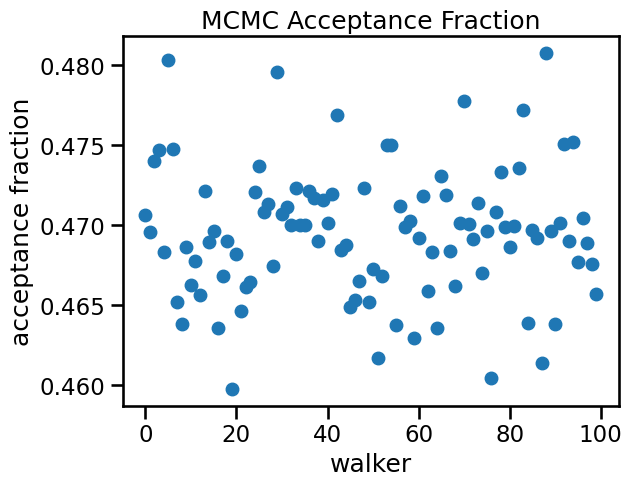

Autocorrelation time for the parameters:
----------------------------------------
r0 = 81.659
sig2 = 92.294
m = 89.722
s0 = 93.757
noise = 118.774


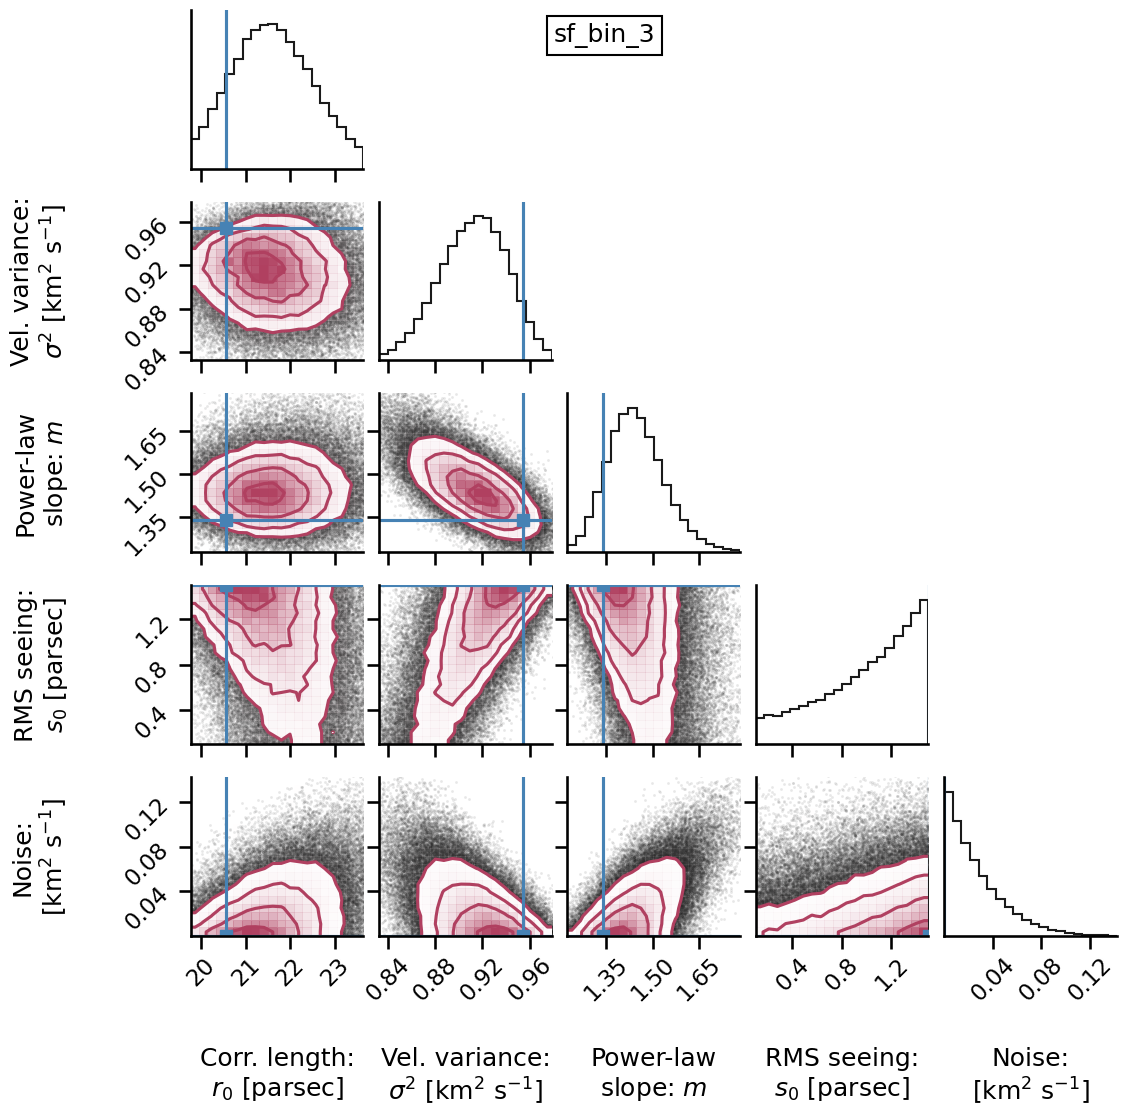

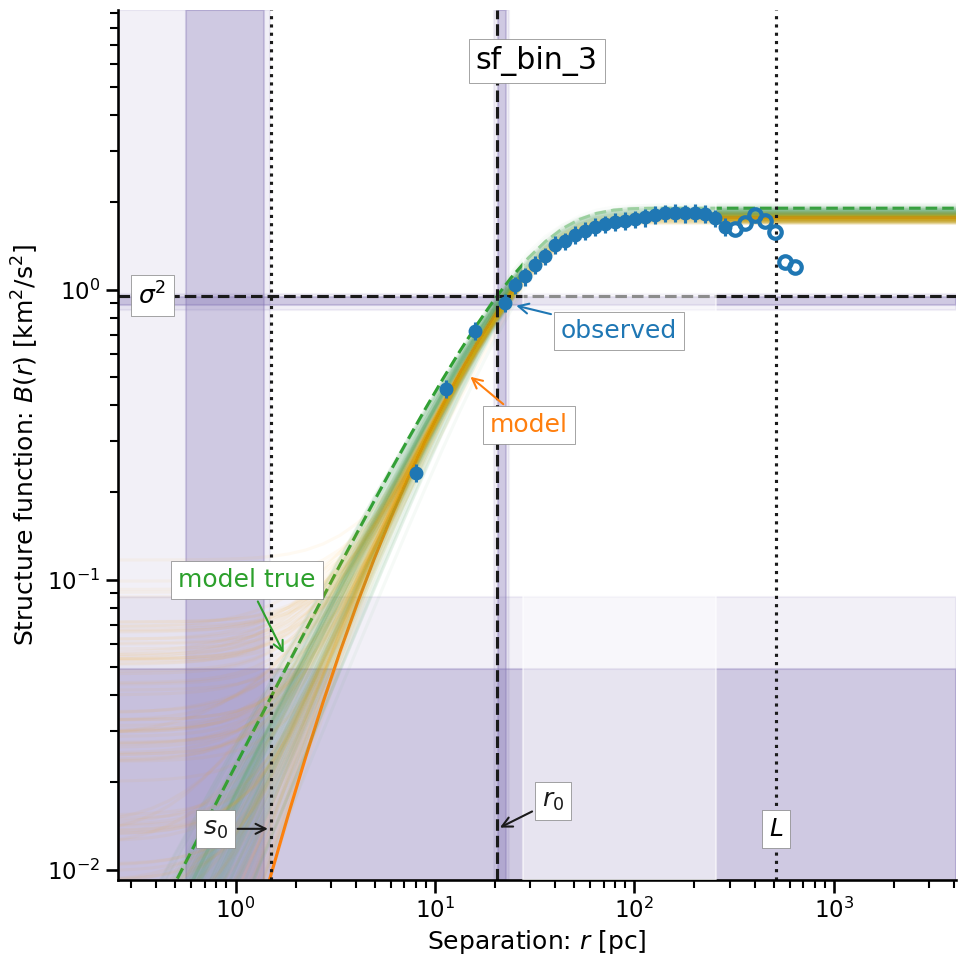

In [42]:
resultsz = fit_structure_function(sfz, N=512, bfunc=bfunc, bplot=bplot, name = 'sf_bin_3', data = 'sf_bin_3', bins = 8)

# bin 4

In [25]:
vmap2Dz_       = pd.notna(vmap2Dz)
bins = 1
mingoods  = [1]*bins

for mingood in zip(mingoods):
 [vmap2Da], vmap2Da_= downsample([vmap2Dz], vmap2Dz_, mingood=mingood)


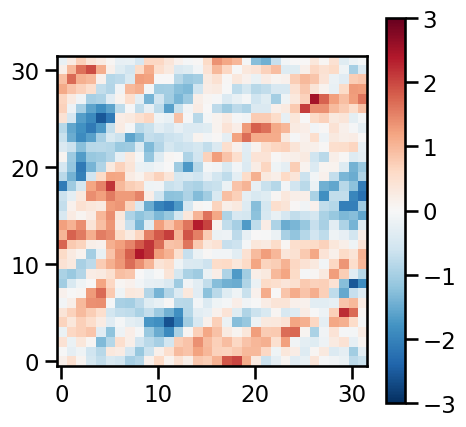

In [26]:

fig, ax = plt.subplots(
    1,
    1,
    #sharey=True,
    figsize=(5, 5),
)

imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap2Da, **imshow_kwds)
fig.colorbar(im)
plt.show()

In [30]:
sfa = strucfunc.strucfunc_numba_parallel(vmap2Da, dlogr=0.05)


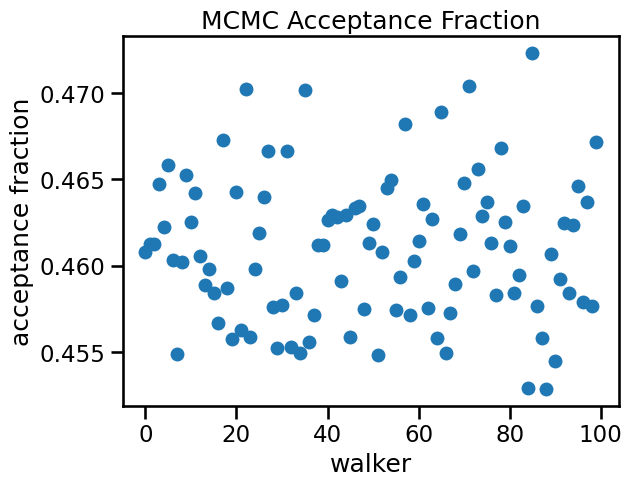

Autocorrelation time for the parameters:
----------------------------------------
r0 = 93.577
sig2 = 106.166
m = 88.590
s0 = 91.392
noise = 117.477


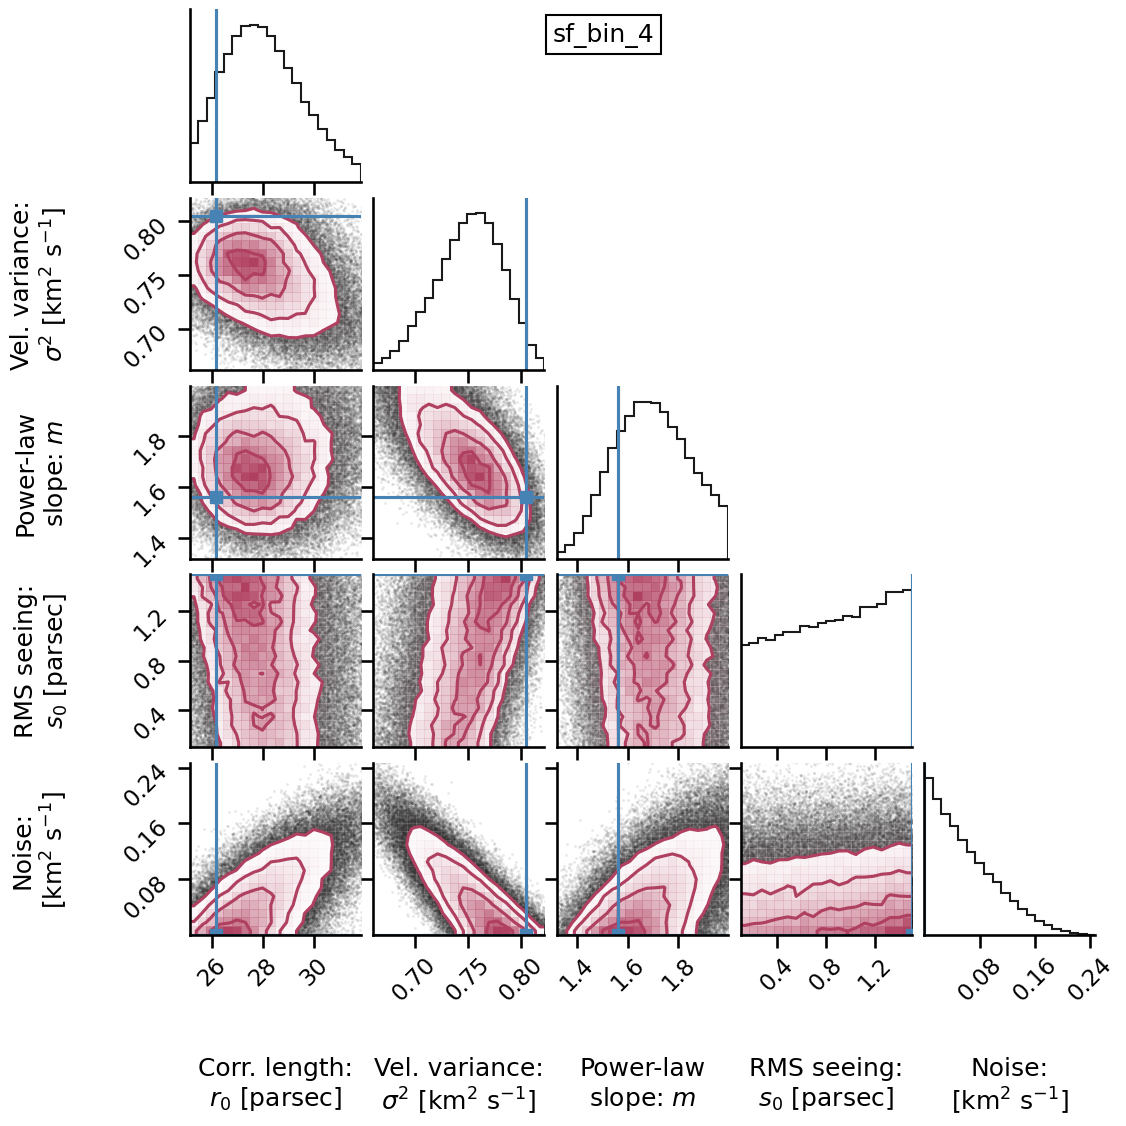

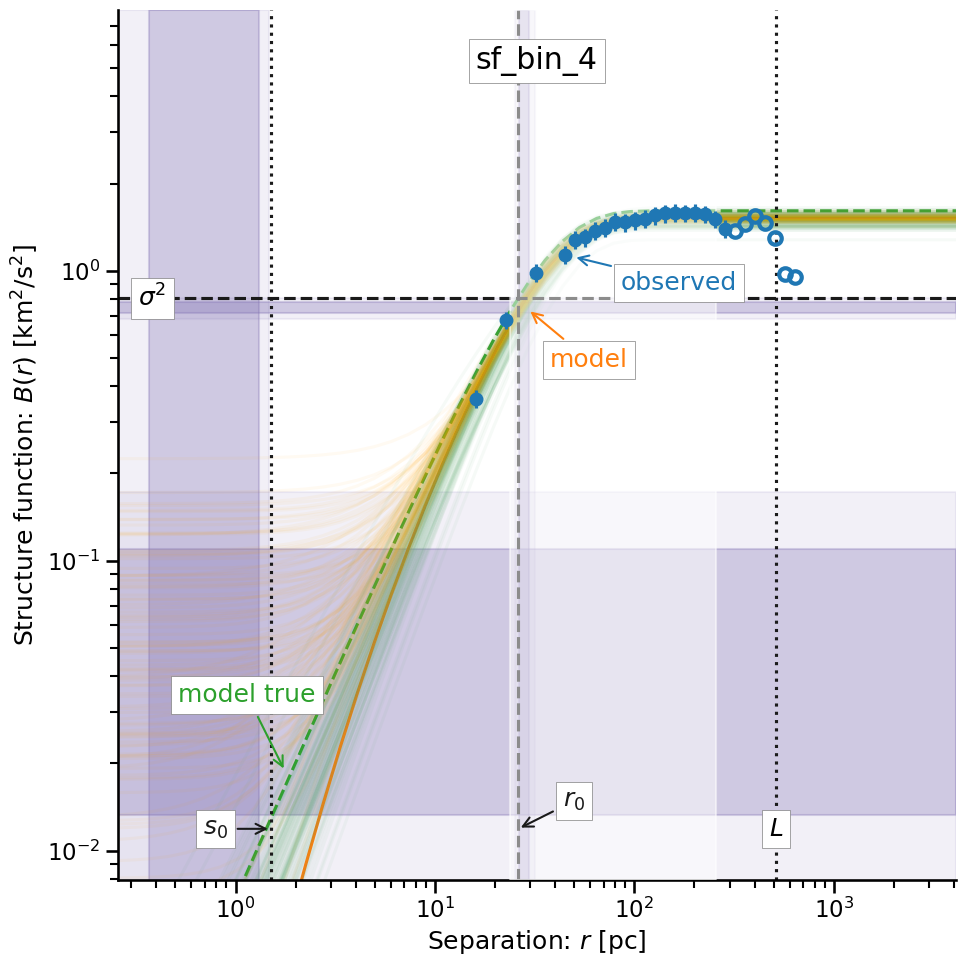

In [37]:
resultsa = fit_structure_function(sfa, N=512, bfunc=bfunc, bplot=bplot, name = 'sf_bin_4', data = 'sf_bin_4', bins = 16)

# bin 5

In [38]:
vmap2Da_       = pd.notna(vmap2Da)
bins = 1
mingoods  = [1]*bins

for mingood in zip(mingoods):
 [vmap2Db], vmap2Db_= downsample([vmap2Da], vmap2Da_, mingood=mingood)


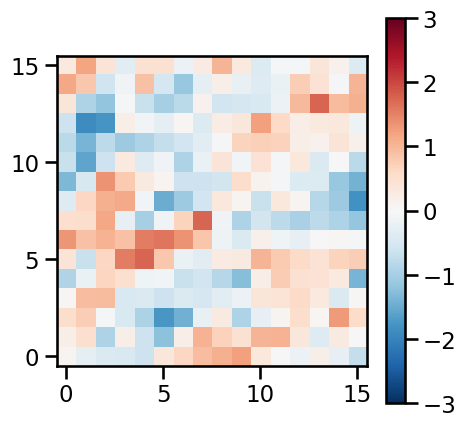

In [39]:

fig, ax = plt.subplots(
    1,
    1,
    #sharey=True,
    figsize=(5, 5),
)

imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap2Db, **imshow_kwds)
fig.colorbar(im)
plt.show()

In [40]:
sfb = strucfunc.strucfunc_numba_parallel(vmap2Db, dlogr=0.05)


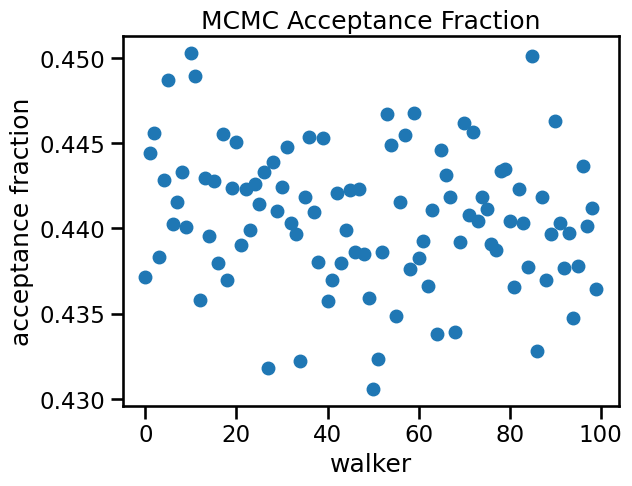

Autocorrelation time for the parameters:
----------------------------------------
r0 = 100.144
sig2 = 109.579
m = 96.960
s0 = 102.068
noise = 113.467


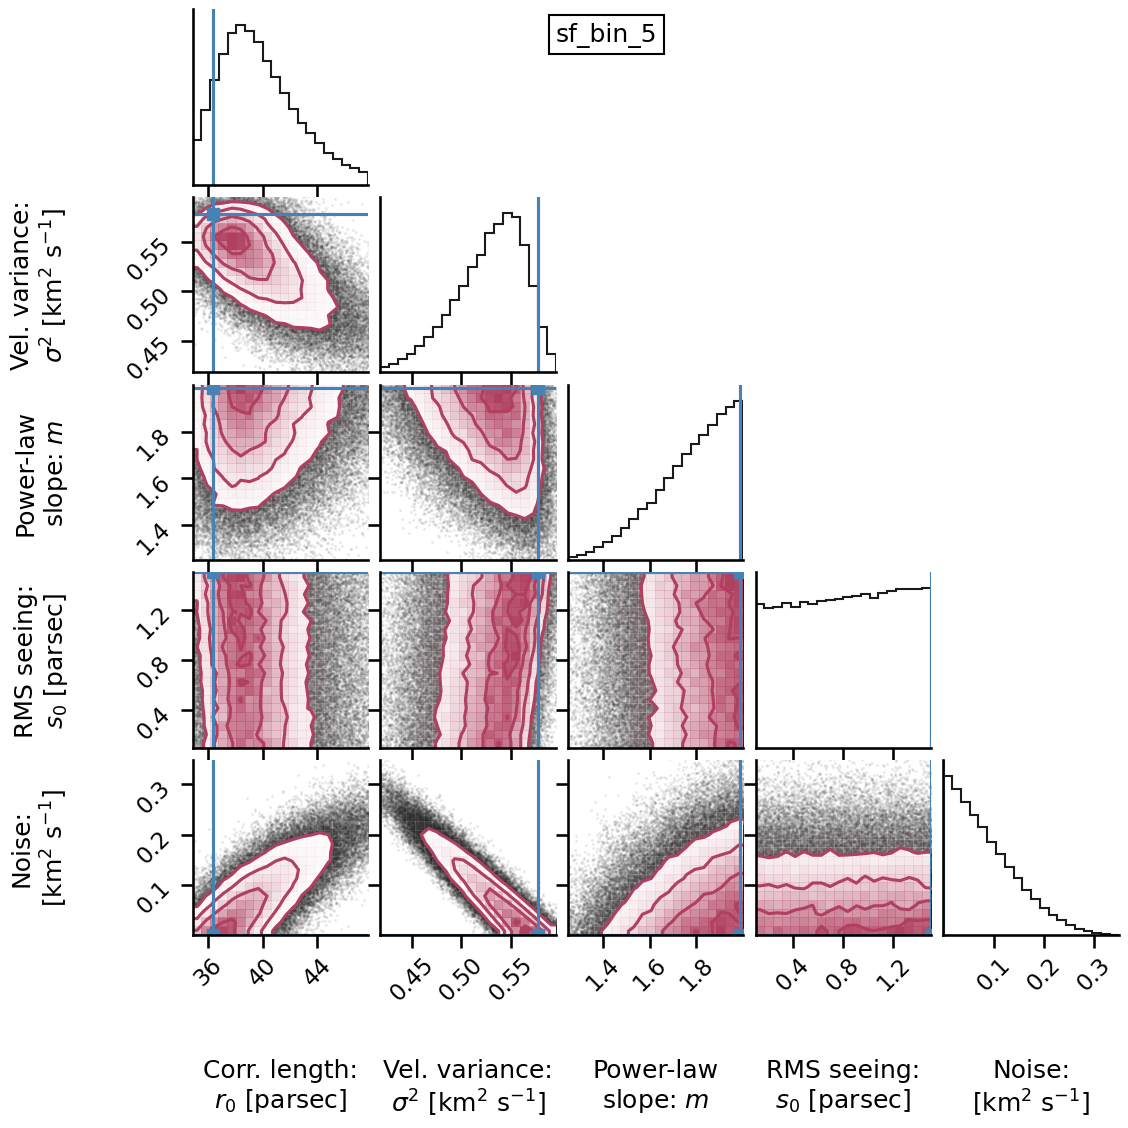

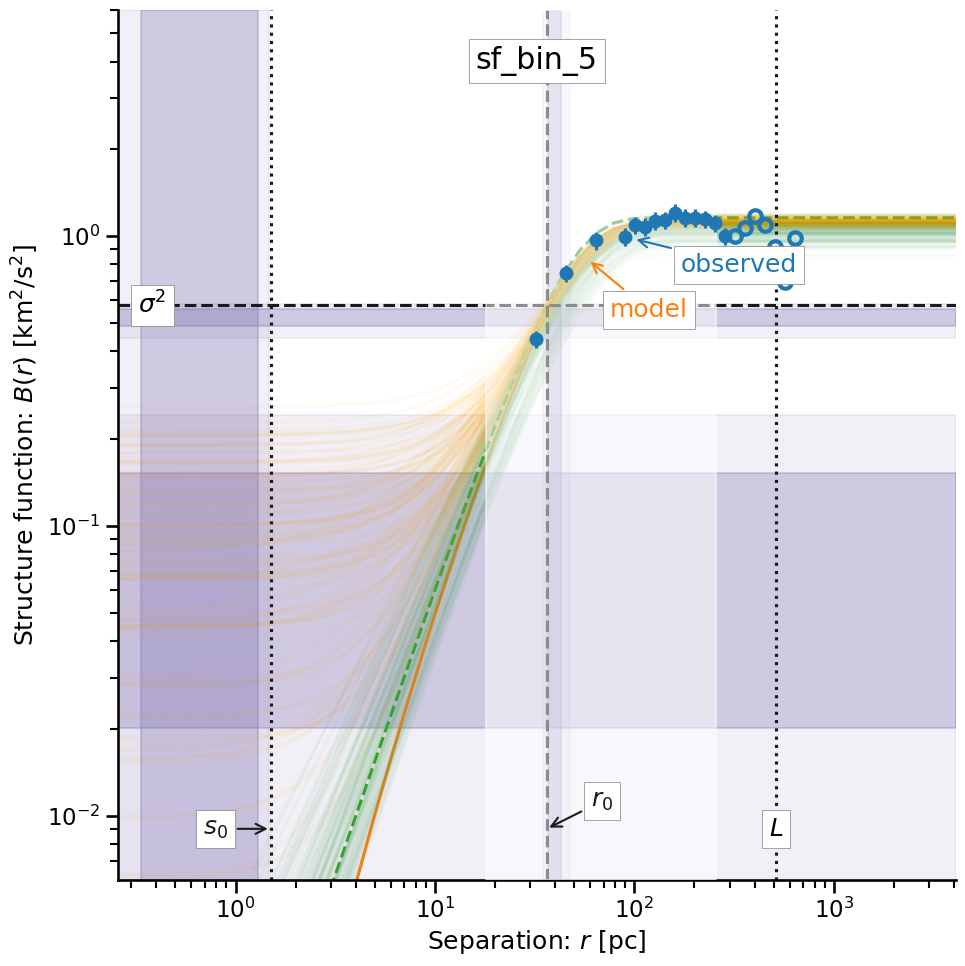

In [41]:
resultsb = fit_structure_function(sfb, N=512, bfunc=bfunc, bplot=bplot, name = 'sf_bin_5', data = 'sf_bin_5', bins = 32)